In [1]:
import punpy
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# function humidity correction
def correction_humidity(temp, relhum): # data from file ?
    k = 216.7  # convertion factor from saturation vapour pressure to water vapour density
    epw = 6.112  # pure water saturation vapour pressure
    a = 17.62  # calibration factor pure water
    b = 243.12  # calibration factor pure water
    water_vap = 0.0054  # atmopheric water vaour scaling factor
    return 1 + water_vap*relhum/100*((epw*np.exp(a*temp/(b+temp)))*k/temp+273.16)

# function for pressure correction
def correction_barometric(press, P0):
    beta = 0.0077
    return np.exp(beta*(press-P0))

# function for solar correction
def correction_solar(M, M0):
    return M0/M

# function for VWC extraction
def measurement_function(temp, relhum, press, P0, M, M0, N_A, N0_A,  N_B, N0_B,  N_C, N0_C, robulk):

  f_humidity = correction_humidity(temp, relhum)
  f_pressure = correction_barometric(press, P0)
  fp = f_humidity * f_pressure
    
  fc = correction_solar(M,M0)

  a0 = 0.0808
  a1 = 0.372
  a2 = 0.115

  vA = (a0/(fp*fc*(N_A/N0_A)-a1) - a2)*robulk
  vB = (a0/(fp*fc*(N_B/N0_B)-a1) - a2)*robulk
  vC = (a0/(fp*fc*(N_C/N0_C)-a1) - a2)*robulk

  return vA, vB, vC

In [3]:
# Read in there datasets
crns_data_1 = pd.read_csv('observations/1_CRNS.txt', delimiter='\t', skiprows=1)
crns_data_2 = pd.read_csv('observations/4_CRNS.txt', delimiter='\t', skiprows=1)
crns_data_3 = pd.read_csv('observations/2_CRNS.txt', delimiter='\t', skiprows=1)

In [4]:
# Filter NAN values and shorten dataset
def filter_df(df):
    df = df[np.invert(np.isnan(df.press1))]
    df = df.head(5000) 
    df["DATE"] = pd.to_datetime(df.datetime)
    df["DATE"] = df["DATE"].dt.round("20min") # Round to 5 mins
    return df

crns_data_1 = filter_df(crns_data_1)
crns_data_2 = filter_df(crns_data_2)
crns_data_3 = filter_df(crns_data_3)

mintime = np.max([np.min(crns_data_1.DATE), np.min(crns_data_2.DATE), np.min(crns_data_3.DATE)])
maxtime = np.min([np.max(crns_data_1.DATE), np.max(crns_data_2.DATE), np.max(crns_data_3.DATE)])


crns_data_1 = crns_data_1[(crns_data_1.DATE > mintime) & (crns_data_1.DATE < maxtime)]
crns_data_2 = crns_data_2[(crns_data_2.DATE > mintime) & (crns_data_2.DATE < maxtime)]
crns_data_3 = crns_data_3[(crns_data_3.DATE > mintime) & (crns_data_3.DATE < maxtime)]

# crns_data_1 = crns_data_1.drop_duplicates(subset="DATE")
# crns_data_2 = crns_data_2.drop_duplicates(subset="DATE")
# crns_data_3 = crns_data_3.drop_duplicates(subset="DATE")

crns_data_1 = crns_data_1.set_index("DATE")
crns_data_2 = crns_data_2.set_index("DATE")
crns_data_3 = crns_data_3.set_index("DATE")


crns_data_2 = (
    crns_data_2
    .reindex(crns_data_1.index)
    .interpolate(method="time")
)

crns_data_3 = (
    crns_data_3
    .reindex(crns_data_1.index)
    .interpolate(method="time")
)

# (optional) restore DATE as column
crns_data_1 = crns_data_1.reset_index()
crns_data_2 = crns_data_2.reset_index()
crns_data_3 = crns_data_3.reset_index()

# Account for tube efficiency
crns_data_1["counts1"] = crns_data_1["counts1"] * 2.0
crns_data_2["counts1"] = crns_data_2["counts1"] * 1.0
crns_data_3["counts1"] = crns_data_3["counts1"] * 2.0 * 2.9


/var/folders/cd/cqgcr8f52t12fwclvgk0l0fm0000gn/T/ipykernel_24626/3668534148.py:35: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  .interpolate(method="time")
/var/folders/cd/cqgcr8f52t12fwclvgk0l0fm0000gn/T/ipykernel_24626/3668534148.py:41: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  .interpolate(method="time")


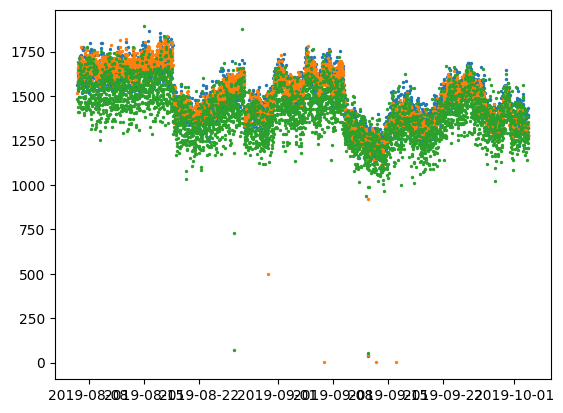

In [5]:
plt.scatter(crns_data_1.DATE, crns_data_1.counts1, s=2) # Large N0 Variability
plt.scatter(crns_data_2.DATE, crns_data_2.counts1, s=2) # Large N0 Variability
plt.scatter(crns_data_3.DATE, crns_data_3.counts1, s=2) # Large N0 Variability
plt.show()

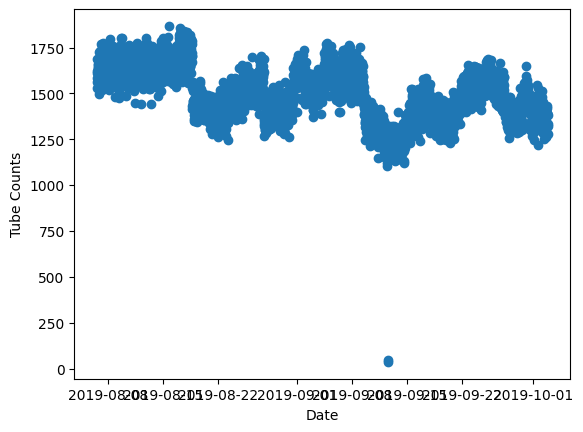

In [6]:
plt.scatter(crns_data_1.DATE, crns_data_1.counts1)
plt.xlabel("Date")
plt.ylabel("Tube Counts")
plt.show()

In [7]:
# Add interpolated NMDB counts at each interval for the period from JUNG data
def add_nmdb(df):
    nmdb_data = pd.read_csv("observations/m0_data.txt", skiprows=25, sep=';')
    
    # Original data
    M = nmdb_data.RCORR_E.array * 3600
    source_time = pd.to_datetime(nmdb_data['start_date_time'].array)  
    
    # Target time array
    target_time = pd.to_datetime(df.DATE)
    
    # Convert to numeric timestamps (seconds since epoch)
    source_ts = source_time.astype('int64') / 1e9
    target_ts = target_time.astype('int64') / 1e9
    
    # Interpolate
    M_interp = np.interp(target_ts, source_ts, M)
    
    # Mean of interpolated array
    M = M_interp * 3600
    
    M0 = np.mean(M)

    df["M"] = M
    df["M0"] = M0

add_nmdb(crns_data_1)
add_nmdb(crns_data_2)
add_nmdb(crns_data_3)

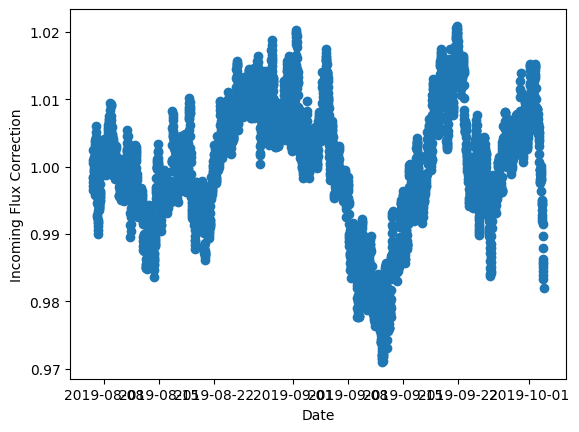

In [8]:
plt.scatter(crns_data_1.DATE, crns_data_1.M/crns_data_1.M0)
plt.xlabel("Date")
plt.ylabel("Incoming Flux Correction")
plt.show()

In [9]:


xvals = []
yvals = []


# run analysis of a single tube
dataset = crns_data_1.copy()

# Rolling 12 h average
avg_period = 24
dataset['sum_counts1'] = crns_data_1['counts1'].rolling(avg_period).sum()
dataset['sum_counts2'] = crns_data_2['counts1'].rolling(avg_period).sum()
dataset['sum_counts3'] = crns_data_3['counts1'].rolling(avg_period).sum()

dataset = dataset[np.invert(np.isnan(dataset['sum_counts1']))]
dataset = dataset[np.invert(np.isnan(dataset['sum_counts2']))]
dataset = dataset[np.invert(np.isnan(dataset['sum_counts3']))]

# def measurement_function(temp, relhum, press, P0, M, M0, N, N0, robulk):
datetime = dataset['DATE'].array

# Define a null error as all being zero
# makes propogation code fail
NULL_ERROR = 1e-4
ones = np.ones(len(dataset))

# Time Series Valuese
temp   = dataset['temp1'].array
press  = dataset['press1'].array
relhum = dataset['relhum1'].array
P0     = np.mean(press) * ones
M      = dataset['M'].array
M0     = dataset['M0'].array
N_A      = dataset['sum_counts1'].array
N0_A     = 4000 * avg_period * ones # placeholder
N_B      = dataset['sum_counts2'].array
N0_B     = 4000 * avg_period * ones # placeholder
N_C      = dataset['sum_counts3'].array
N0_C     = 4000 * avg_period * ones # placeholder
robulk = 1.31 * ones

# Random Uncertainty
temp_ur   = 0.1 * ones
press_ur  = 0.002 * ones # 0.002 hPa
relhum_ur = 0.03 * relhum
P0_ur     = 0.0 * ones
M_ur      = np.sqrt(M) 
M0_ur     = 0.0 * ones
N_A_ur      = np.sqrt(N_A) 
N0_A_ur     = np.sqrt(N0_A) 
N_B_ur      = np.sqrt(N_B) 
N0_B_ur     = np.sqrt(N0_B) 
N_C_ur      = np.sqrt(N_C) 
N0_C_ur     = np.sqrt(N0_C) 
robulk_ur = 0.06 * ones

# Systematic Uncertainty
temp_us   = 1.0 * ones
press_us  = 2.0 * ones
relhum_us = 0.03 * relhum
P0_us     = NULL_ERROR * ones
M_us      = 0.0072 * M
M0_us     = 0.0072 * M0
N_A_us      = 0.04 * N_A
N0_A_us     = 0.04 * N0_A
N_B_us      = 0.04 * N_B
N0_B_us     = 0.04 * N0_B
N_C_us     = 0.04 * N_C
N0_C_us     = 0.04 * N0_C
robulk_us = NULL_ERROR * ones

# Monte Carlo propagation
names = ["T [C]", "RH [%]", "P [hPa]", "P0 [hPa]", "M", "M0", "N_A", "N0_A", "N_B", "N0_B", "N_C", "N0_C", "rho [g/m3]"]
parameters = [temp, relhum, press, P0, M, M0, N_A, N0_A, N_B, N0_B, N_C, N0_C, robulk]
randoms    = [temp_ur, relhum_ur, press_ur, P0_ur, M_ur, M0_ur, N_A_ur, N0_A_ur, N_B_ur, N0_B_ur, N_C_ur, N0_C_ur, robulk_ur]
systematics= [temp_us, relhum_us, press_us, P0_us, M_us, M0_us, N_A_us, N0_A_us, N_B_us, N0_B_us, N_C_us, N0_C_us, robulk_us]

prop = punpy.MCPropagation(1000)

vwc = measurement_function(temp, relhum, press, P0, M, M0, N_A, N0_A, N_B, N0_B, N_C, N0_C,  robulk) # need to add N, N0, robulk

vwc_ur, vwc_ur_samples, vwc_ur_throws = prop.propagate_random(measurement_function, 
                               parameters, randoms, return_samples=True, output_vars=3)

vwc_us, vwc_us_samples, vwc_us_throws = prop.propagate_systematic(measurement_function, 
                                   parameters, systematics, return_samples=True, output_vars=3)





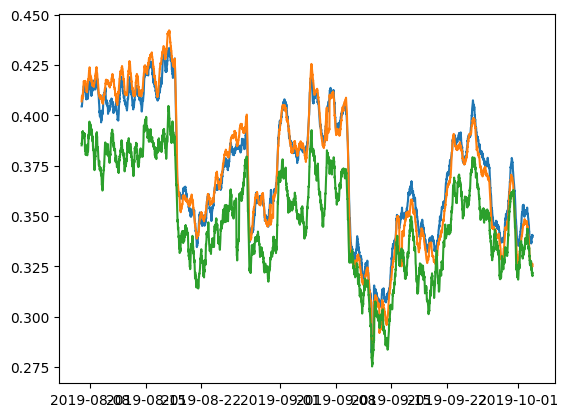

In [10]:
plt.plot(dataset["DATE"], N_A/N0_A)
plt.plot(dataset["DATE"], N_B/N0_B)
plt.plot(dataset["DATE"], N_C/N0_C)
plt.show()

# plt.plot(dataset["DATE"], vwc[0])
# plt.show()

0.8959145087788735
0.8934694313966399
0.8914876136094554


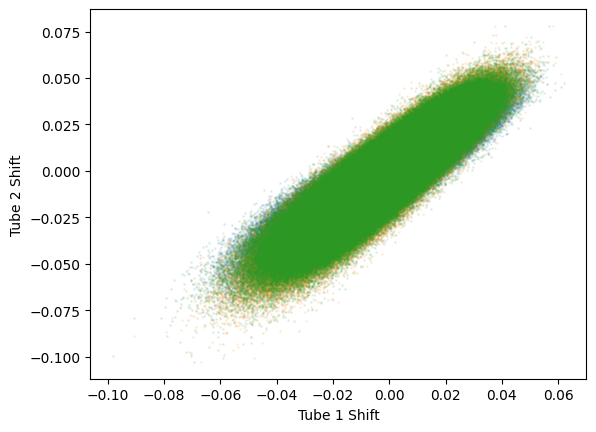

In [11]:
plt.scatter((vwc[0]-vwc_ur_samples[:,0,:]).ravel(), (vwc[1]-vwc_ur_samples[:,1,:]).ravel(), s=1, alpha=0.1)
plt.scatter((vwc[0]-vwc_ur_samples[:,0,:]).ravel(), (vwc[2]-vwc_ur_samples[:,2,:]).ravel(), s=1, alpha=0.1)
plt.scatter((vwc[1]-vwc_ur_samples[:,1,:]).ravel(), (vwc[2]-vwc_ur_samples[:,2,:]).ravel(), s=1, alpha=0.1)
plt.xlabel("Tube 1 Shift")
plt.ylabel("Tube 2 Shift")
x = (vwc[0]-vwc_ur_samples[:,0,:]).ravel()
y = (vwc[1]-vwc_ur_samples[:,1,:]).ravel()
r01 = np.corrcoef(x, y)[0, 1]
print(r01)

x = (vwc[0]-vwc_ur_samples[:,0,:]).ravel()
y = (vwc[2]-vwc_ur_samples[:,2,:]).ravel()
r02 = np.corrcoef(x, y)[0, 1]
print(r02)

x = (vwc[1]-vwc_ur_samples[:,1,:]).ravel()
y = (vwc[2]-vwc_ur_samples[:,2,:]).ravel()
r12 = np.corrcoef(x, y)[0, 1]
print(r12)

plt.show()

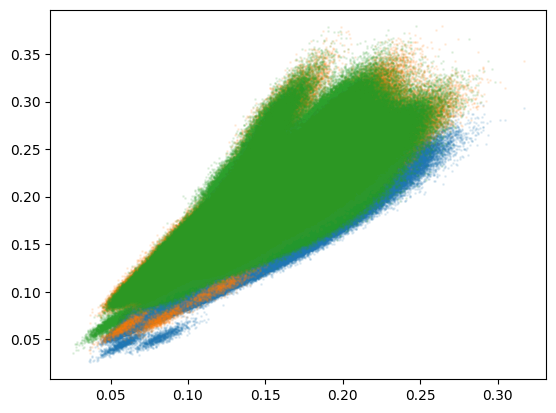

(1000, 4102) (1000, 4102)


/Users/stowell/.envs/cosmicswamp/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


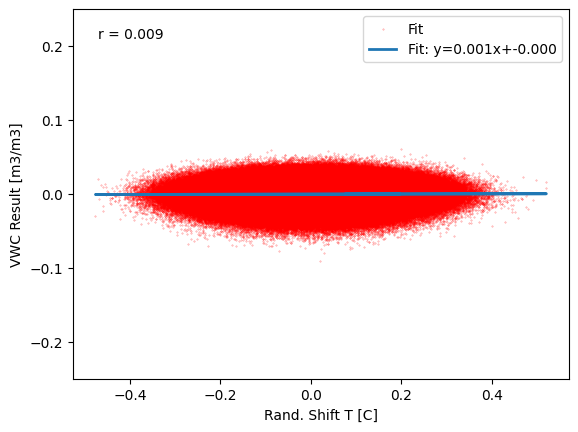

(1000, 4102) (1000, 4102)


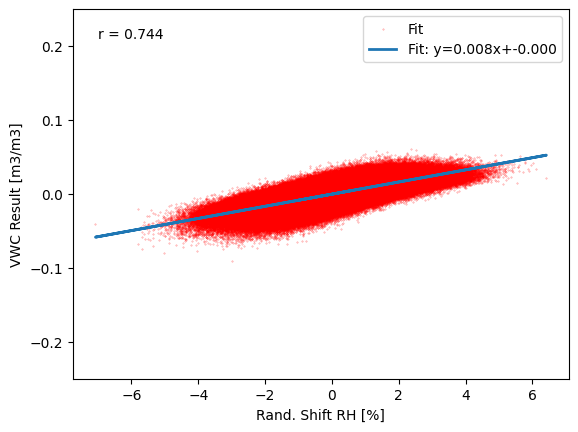

(1000, 4102) (1000, 4102)


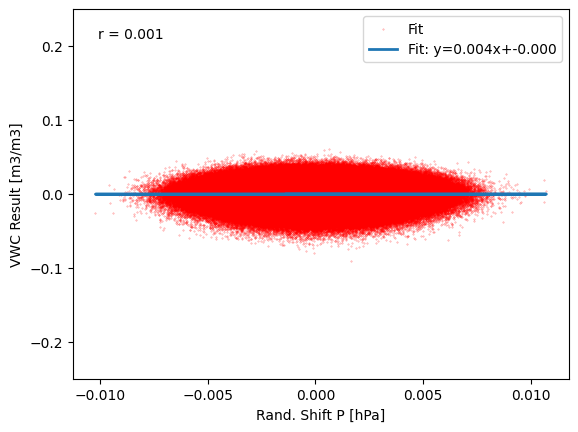

(1000, 4102) (1000, 4102)


/Users/stowell/.envs/cosmicswamp/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3063: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/stowell/.envs/cosmicswamp/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3064: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/stowell/.envs/cosmicswamp/lib/python3.13/site-packages/numpy/lib/_polynomial_impl.py:674: RuntimeWarning: invalid value encountered in divide
  lhs /= scale


(1000, 4102) (1000, 4102)


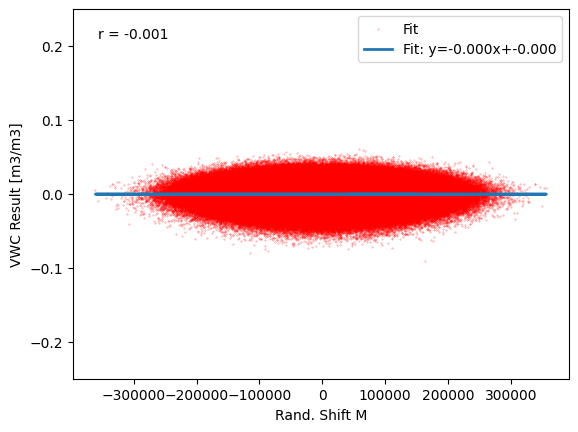

(1000, 4102) (1000, 4102)
(1000, 4102) (1000, 4102)


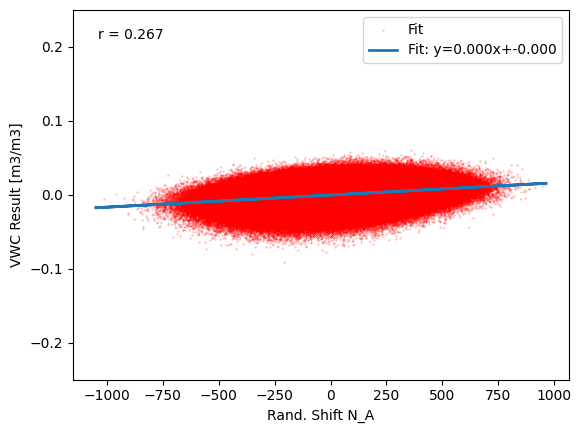

(1000, 4102) (1000, 4102)


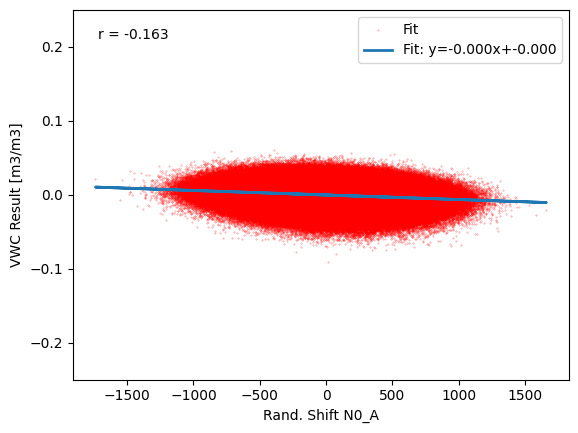

(1000, 4102) (1000, 4102)


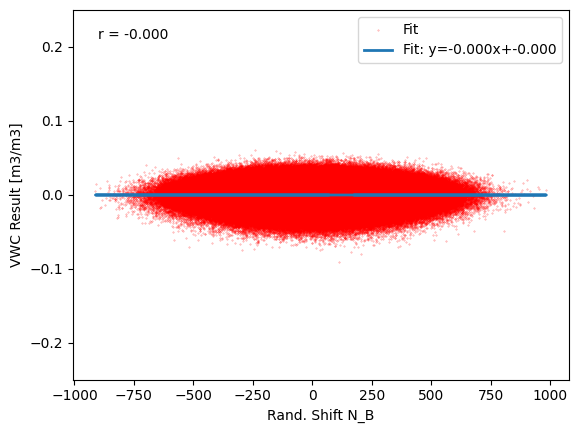

(1000, 4102) (1000, 4102)


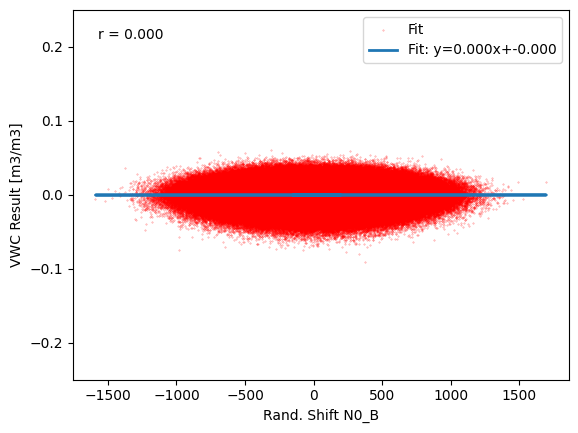

(1000, 4102) (1000, 4102)


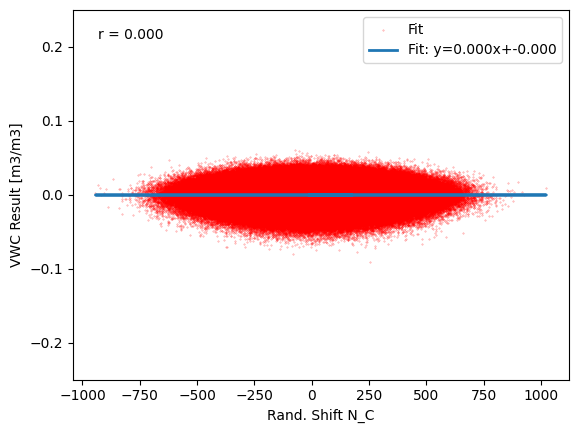

(1000, 4102) (1000, 4102)


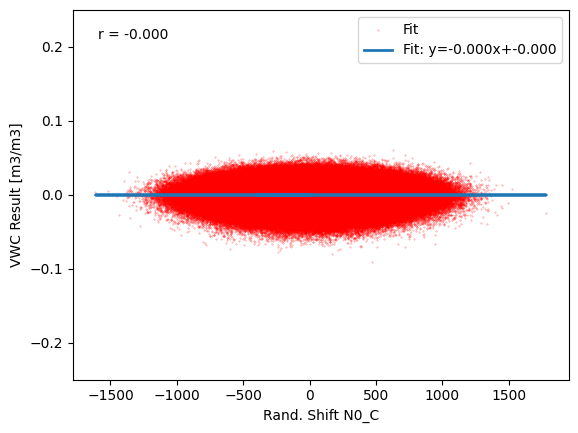

(1000, 4102) (1000, 4102)


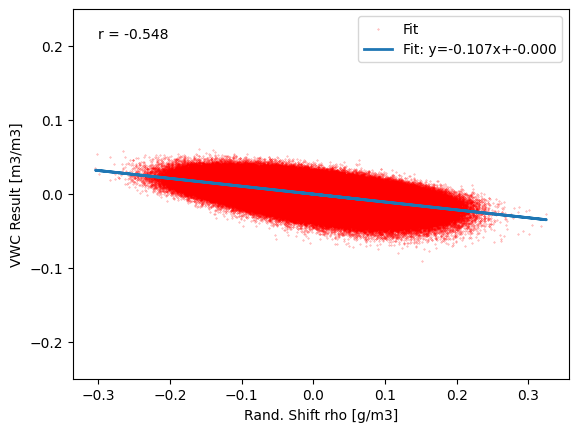

(1000, 4102) (1000, 4102)


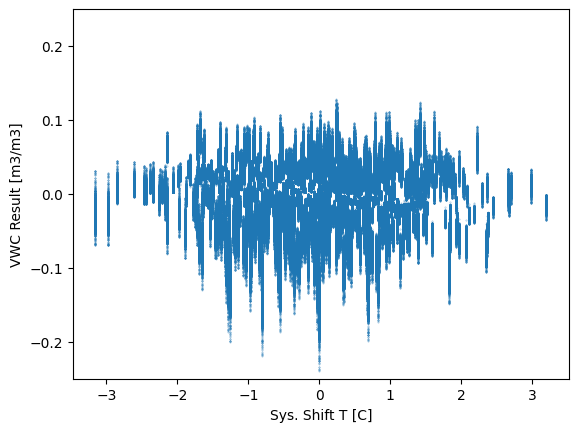

(1000, 4102) (1000, 4102)


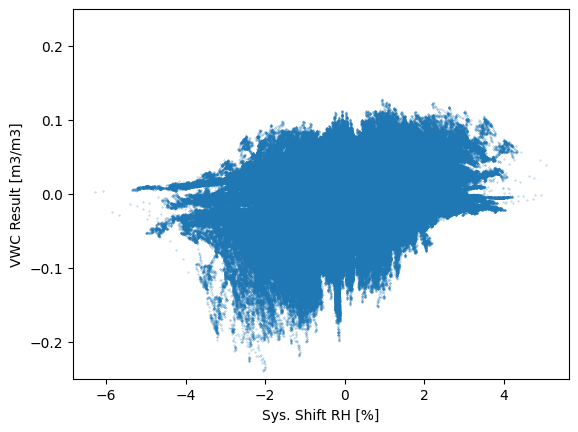

(1000, 4102) (1000, 4102)


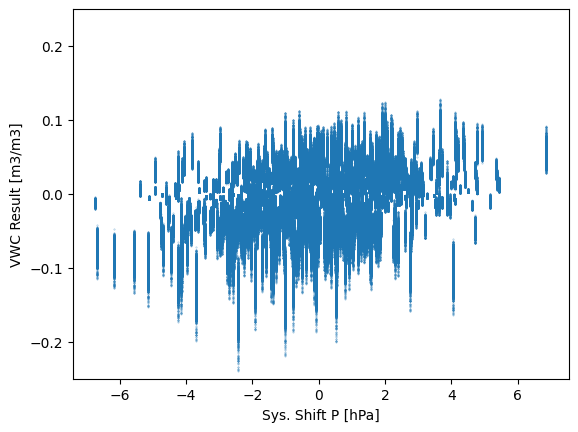

(1000, 4102) (1000, 4102)


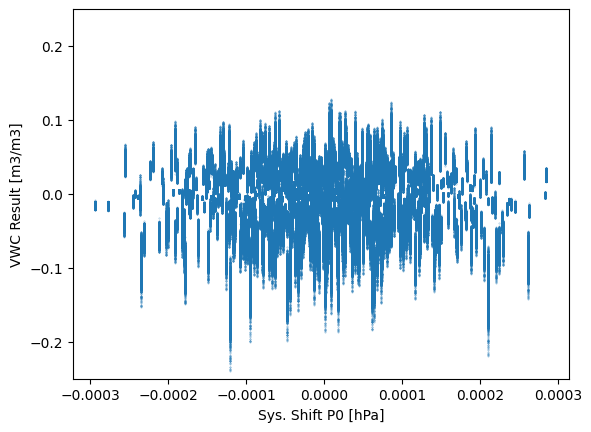

(1000, 4102) (1000, 4102)


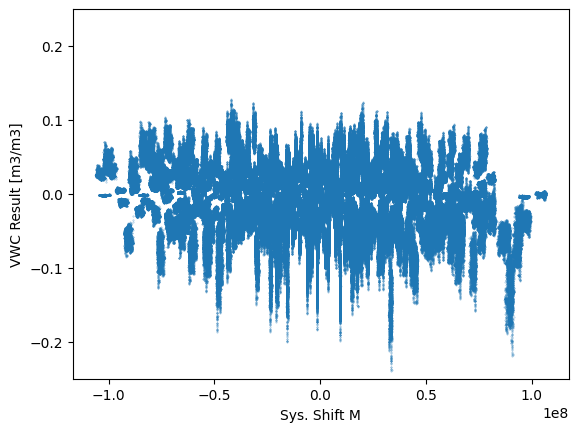

(1000, 4102) (1000, 4102)


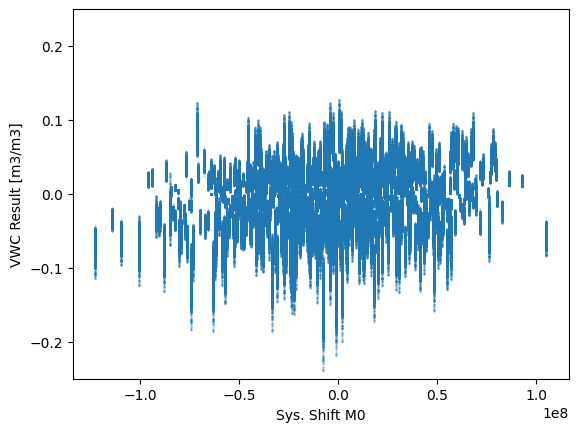

(1000, 4102) (1000, 4102)


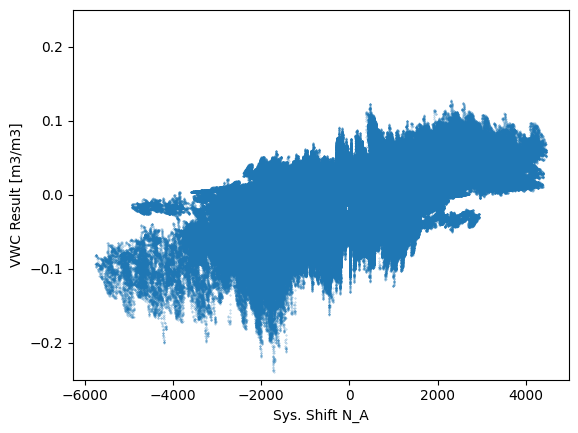

(1000, 4102) (1000, 4102)


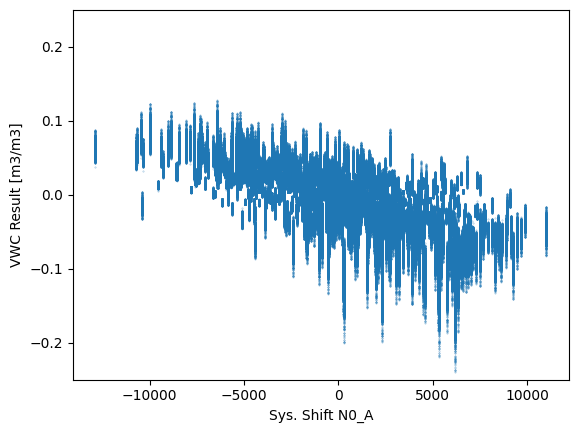

(1000, 4102) (1000, 4102)


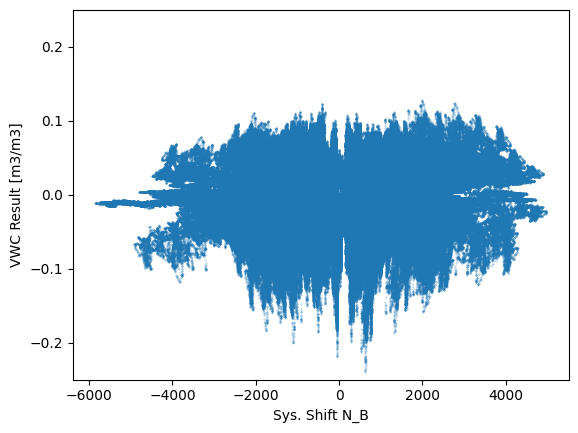

(1000, 4102) (1000, 4102)


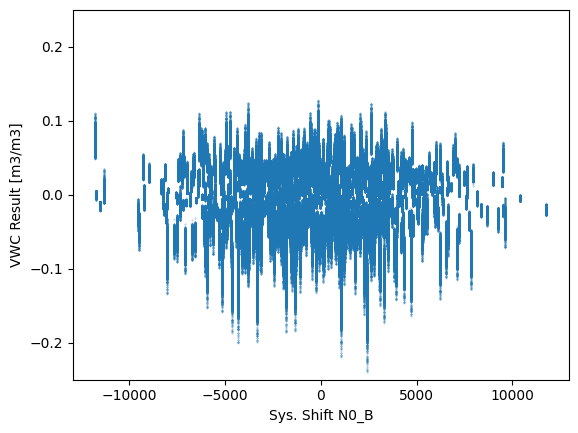

(1000, 4102) (1000, 4102)


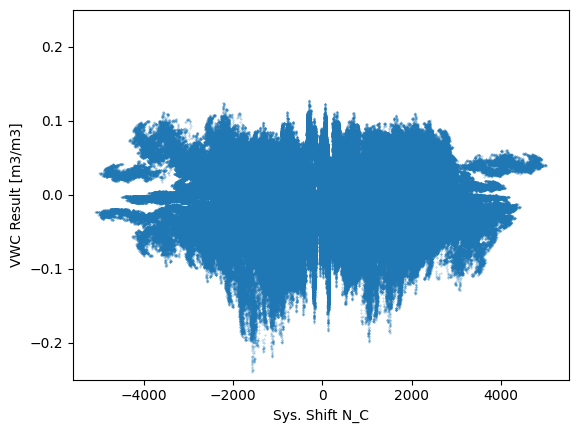

(1000, 4102) (1000, 4102)


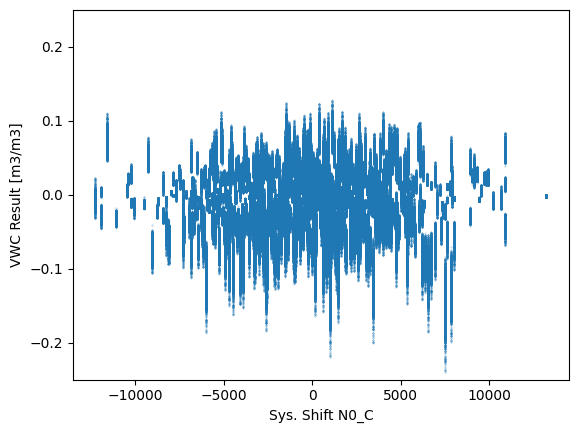

(1000, 4102) (1000, 4102)


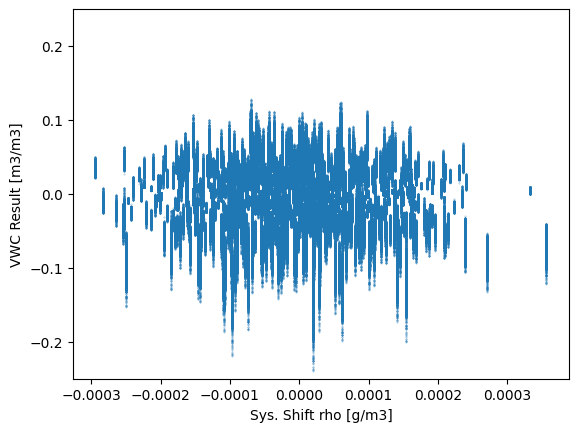

[0.01323959 0.01356002 0.01317965 ... 0.01047718 0.01037869 0.01015383] (3, 4102)
[0.04317929 0.04276463 0.04284686 ... 0.03054037 0.03030334 0.02985972] (3, 4102)


ValueError: operands could not be broadcast together with shapes (12306,1) (3,3) 

In [12]:

plt.scatter(vwc_ur_samples[:,0,:].ravel(), vwc_ur_samples[:,1,:].ravel(), s=1, alpha=0.1)
plt.scatter(vwc_ur_samples[:,0,:].ravel(), vwc_ur_samples[:,2,:].ravel(), s=1, alpha=0.1)
plt.scatter(vwc_ur_samples[:,1,:].ravel(), vwc_ur_samples[:,2,:].ravel(), s=1, alpha=0.1)
# plt.xlim([0.0,0.2])
# plt.ylim([0.0,0.2])
plt.show()



import numpy as np

for i in range(len(parameters)):
    try:
        print(vwc_ur_throws[i].shape, vwc_us_samples[:,0,:].shape)
        
        x = (vwc_ur_throws[i] - parameters[i]).ravel()
        y = (vwc[0] - vwc_ur_samples[:,0,:]).ravel()
        
        # Remove NaNs if present
        # mask = np.isfinite(x) & np.isfinite(y)
        # x, y = x[mask], y[mask]
        
        # --- Correlation ---
        r = np.corrcoef(x, y)[0, 1]
        
        # --- Linear fit ---
        m, b = np.polyfit(x, y, 1)
        y_fit = m * x + b
        
        # --- Plot ---
        plt.figure()
        plt.scatter(x, y, s=0.1, alpha=0.5, label="Fit", color='red')
        
        # Regression line
        plt.plot(x, y_fit, linewidth=2, label=f"Fit: y={m:.3f}x+{b:.3f}")
        
        # Labels + annotation
        plt.xlabel("Rand. Shift " + names[i])
        plt.ylabel("VWC Result [m3/m3]")
        plt.ylim([-0.25, 0.25])
        
        # Correlation text on plot
        plt.text(0.05, 0.95, f"r = {r:.3f}", transform=plt.gca().transAxes,
                 verticalalignment='top')
        
        plt.legend()
        plt.show()
    except:
        pass

    
# for i in range(len(parameters)):
#     print(vwc_ur_throws[i].shape, vwc_us_samples[:,0,:].shape)
#     plt.scatter((vwc_ur_throws[i]-parameters[i]).ravel(), (vwc[0] - vwc_ur_samples[:,0,:]).ravel(), s=0.1, alpha=0.5, label="Random")
#     plt.xlabel("Rand. Shift " + names[i])
#     plt.ylabel("VWC Result [m3/m3]")
#     plt.ylim([-0.25,0.25])
#     plt.show()

for i in range(len(parameters)):
    print(vwc_ur_throws[i].shape, vwc_us_samples[:,0,:].shape)
    plt.scatter((vwc_us_throws[i]-parameters[i]).ravel(), (vwc[0] - vwc_us_samples[:,0,:]).ravel(), s=0.1, alpha=0.5, label="Systematic")
    plt.xlabel("Sys. Shift " + names[i])
    plt.ylabel("VWC Result [m3/m3]")
    plt.ylim([-0.25,0.25])
    
    plt.show()


print(vwc_ur[0], vwc_ur.shape)
print(vwc_us[0], vwc_us.shape)

vwc_ut = (vwc_ur**2 + vwc_us**2)**0.5

vwc_cov = punpy.convert_corr_to_cov(np.eye(len(vwc_ur)), vwc_ur) + \
           punpy.convert_corr_to_cov(np.ones((len(vwc_us), len(vwc_us))), vwc_us)
vwc_corr = punpy.correlation_from_covariance(vwc_cov)


# # Define bins
# bins = np.arange(0, 1.05, 0.01)

# # Digitize vwc into bins
# indices = np.digitize(vwc, bins)

# # Compute bin centers and means
# bin_centers = 0.5 * (bins[:-1] + bins[1:])
# means = [vwc_ut[indices == i].mean() if np.any(indices == i) else np.nan
#          for i in range(1, len(bins))]

# errors = [vwc_ut[indices == i].std() / np.sqrt(np.sum(indices == i))
#       if np.sum(indices == i) > 0 else np.nan
#       for i in range(1, len(bins))]

# # Plot profile histogram
# plt.plot(bin_centers, means, label=f'test')

# plt.ylim([0.0,0.2])
# plt.legend()
# plt.show()

In [ ]:
prop = punpy.MCPropagation(10000)

vwc = measurement_function(temp, relhum, press, P0, M, M0, N, N0, robulk) # need to add N, N0, robulk

vwc_ur = prop.propagate_random(measurement_function, 
                               parameters, randoms)

vwc_us = prop.propagate_systematic(measurement_function, 
                                   parameters, systematics)

vwc_ut = (vwc_ur**2 + vwc_us**2)**0.5

vwc_cov = punpy.convert_corr_to_cov(np.eye(len(vwc_ur)), vwc_ur) + \
           punpy.convert_corr_to_cov(np.ones((len(vwc_us), len(vwc_us))), vwc_us)
vwc_corr = punpy.correlation_from_covariance(vwc_cov)

# Show approximate range of errors
plt.scatter(datetime, vwc-vwc_ut, s=2, label='low')
plt.scatter(datetime, vwc+vwc_ut, s=2, label='high')
plt.scatter(datetime, vwc, s=2, label='mid')
plt.ylim([0.0,1.0])
plt.xlabel("Date")
plt.ylabel("SM [m3/m3]")
plt.show()


In [ ]:

plt.scatter(vwc, vwc_ut, s=2)
plt.xlim([0.0,1.0])
plt.ylim([0.0,0.2])
plt.xlabel("SM [m3/m3]")
plt.ylabel("SM Uncertainty %")
plt.show()

plt.scatter(vwc, vwc_ut/vwc, s=2)
plt.xlim([0.0,1.0])
plt.ylim([0.0,1.0])
plt.xlabel("SM [m3/m3]")
plt.ylabel("Rel. SM Uncertainty %")
plt.show()